**Salve, carissimum lector!** In this PIC 16B assignment, we'll be modeling heat diffusion in two dimensions. The famous heat equation in two dimensions has the form:
$$
\frac{\partial f}{\partial t} = \frac{\partial ^2 f}{\partial x^2} + \frac{\partial ^2 f}{\partial y^2}
$$

But this equation is for continuous time and space. Our goal is to use matrix multiplication/numpy operations to model this process, where every multiplication represents a step in discrete time, and space is separated into little "chunks". But as long as our discretization is large enough, the effect will be mostly the same. First let:
$$
x_i = i\Delta x, y_j = j\Delta y, t_k = k \Delta t
$$
for $i = 0, \cdots, N-1, j = 0, \cdots, N-1, k = 0, \cdots, N-1$, be the discrete representations of points in space and time steps. Then for time $t_k$, we use the following to compute the temperature, $u$, at a given point $(x_i, y_j)$ at time $t_{k+1}$:
$$
u^{k+1}_{i,j} \approx u^{k}_{i,j} + \epsilon ( u^{k}_{i+1,j} +  u^{k}_{i-1,j} + u^{k}_{i,j+1} +  u^{k}_{i,j-1} - 4  u^{k}_{i,j})
$$
where $\epsilon$ is some small control parameter that controlls the rate of diffusion. Note the intution, the point "receives" heat from its (4) surrounding points, but also "gives off" heat to those same (4) surrounding points. 

In these simulations, we'll set $N = 101$ giving us $101^2$ points in our solution, and $\epsilon = 0.2$.

In [1]:
N = 101
epsilon = 0.2

Next, we'll set our initial condition, setting a point in the middle to have a heat of $1$. 

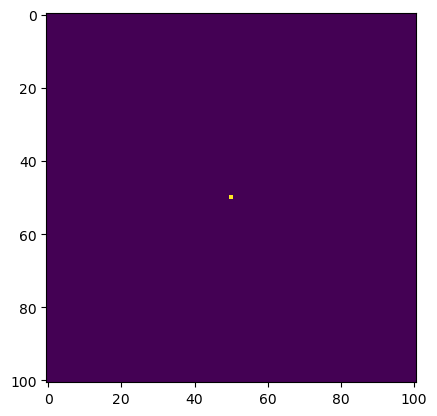

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import timeit
# construct initial condition: 1 unit of heat at midpoint. 
u0 = np.zeros((N, N))
u0[int(N/2), int(N/2)] = 1.0
plt.imshow(u0)

We'll be trying out four different ways of running this simulation, which will (hopefully) get faster which each one. Our first method will be using Pythons built-in linear algebra methods and matrix multiplication. The function `advance_time_matvecmul` essentially performs the approximation calculation for one time step, by taking in `u`, which is the solution array (space), flattening it into a vector, then multiplying it with a matrix `A` that represents the linear transformation for heat across one time step. It then reshapes `u` after, and returns it.

The function `get_A` takes in an integer, `N`, and returns the matrix (numpy array) that performs the heat diffusion approximation transformation. 

In [3]:
def advance_time_matvecmul(A, u, epsilon):
    """Advances the simulation by one timestep, via matrix-vector multiplication
    Args:
        A: The 2d finite difference matrix, N^2 x N^2. 
        u: N x N grid state at timestep k.
        epsilon: stability constant.

    Returns:
        N x N Grid state at timestep k+1.
    """
    N = u.shape[0]
    u = u + epsilon * (A @ u.flatten()).reshape((N, N))
    return u

In [4]:
def get_A(N):
    n = N * N
    diagonals = [-4 * np.ones(n), np.ones(n-1), np.ones(n-1), np.ones(n-N), np.ones(n-N)]
    diagonals[1][(N-1)::N] = 0
    diagonals[2][(N-1)::N] = 0
    A = np.diag(diagonals[0]) + np.diag(diagonals[1], 1) + np.diag(diagonals[2], -1) + np.diag(diagonals[3], N) + np.diag(diagonals[4], -N)
    return A

#### Matrix Multiplication

Alright, let's simulate! We'll run it for $2700$ timesteps, and plot the heatmap at every $300$ steps. Then, we'll time this process (without the plotting) to see how fast/slow it is.

In [5]:
# For with matrices
def simulate(sim_function, A, u, epsilon):
    fig, axarr = plt.subplots(3, 3, figsize = (15, 10))
    for t in range(1, 2701):
        if t % 300 == 0:
            ax = t//300 - 1
            ax_row = ax//3
            ax_col = ax%3
            axarr[ax_row, ax_col].imshow(u)
            axarr[ax_row, ax_col].set_title(f"t = {t}") 
        u = sim_function(A, u, epsilon)
    plt.show()

# For without matrices
def simulate2(sim_function, u, epsilon):
    fig, axarr = plt.subplots(3, 3, figsize = (15, 10))
    for t in range(1, 2701):
        if t % 300 == 0:
            ax = t//300 - 1
            ax_row = ax//3
            ax_col = ax%3
            axarr[ax_row, ax_col].imshow(u)
            axarr[ax_row, ax_col].set_title(f"t = {t}") 
        u = sim_function(u, epsilon)
    plt.show()

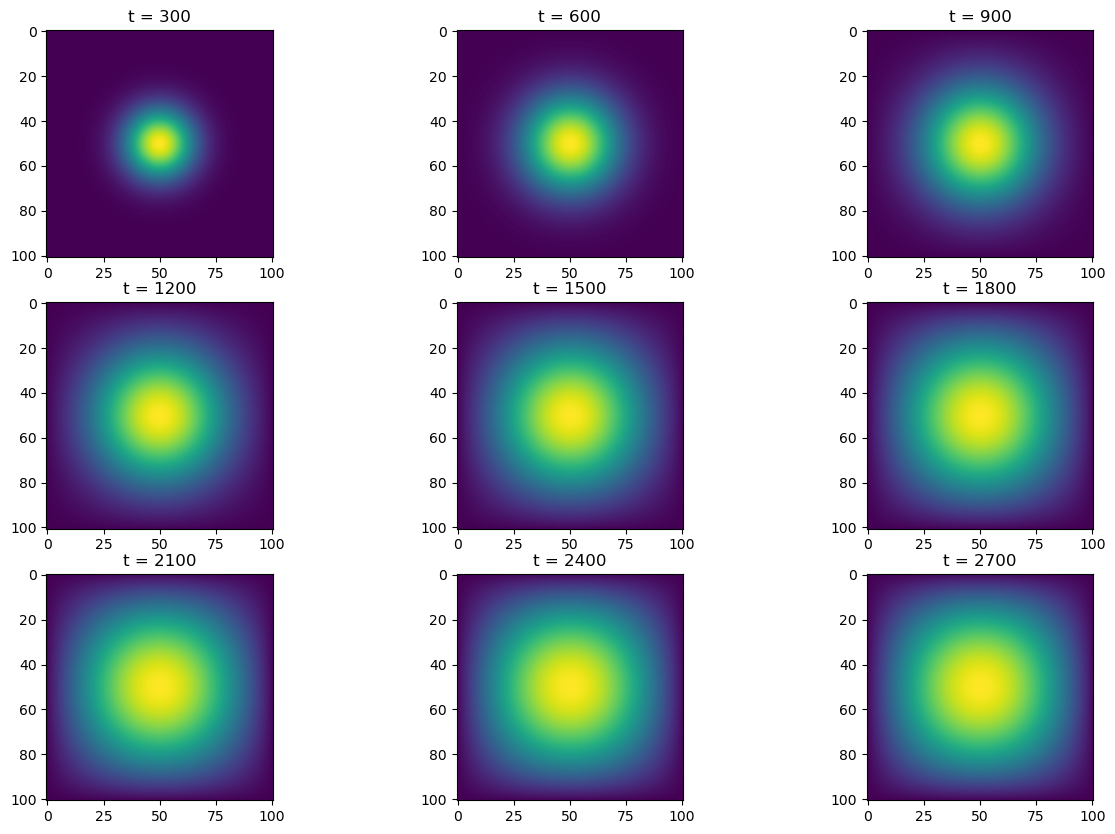

In [6]:
A = get_A(N)
simulate(advance_time_matvecmul, A, u0, epsilon)

In [7]:
%%timeit
u = advance_time_matvecmul(A, u0, epsilon)
for t in range(2, 2701):
    u = advance_time_matvecmul(A, u, epsilon)

2min 30s ± 4.4 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


Alright, an average runtime of `150s`; that is pretty slow. It makes sense, since our matrix is $N^2 \times N^2$, and we're performing $2700$ matrix multiplications. Let's see if we can improve this time with our next method.

### Sparse Matrices and Jax Jitting

When we create our numpy matrix, it has a lot of 0 entries, and `advance_time_matvecmul` wastes a lot of time computing these values. We can use jax's experimental *sparse* matrices to hopefully alleviate this. We'll define `get_sparse_A` which takes in an integer $N$, computes the normal matrix with `get_A`, then transform it into a sparse matrix. 

In [8]:
import jax
import jax.numpy as jnp
from jax.experimental import sparse

In [9]:
def get_sparse_A(N):
    A = get_A(N)
    A_sp_matrix = sparse.BCOO.fromdense(A)
    return A_sp_matrix

Since we're using jax as well, we can *jit* our functions to speed up their computations using "just-in-time" compilation as well. Let's simulate how this method performs.

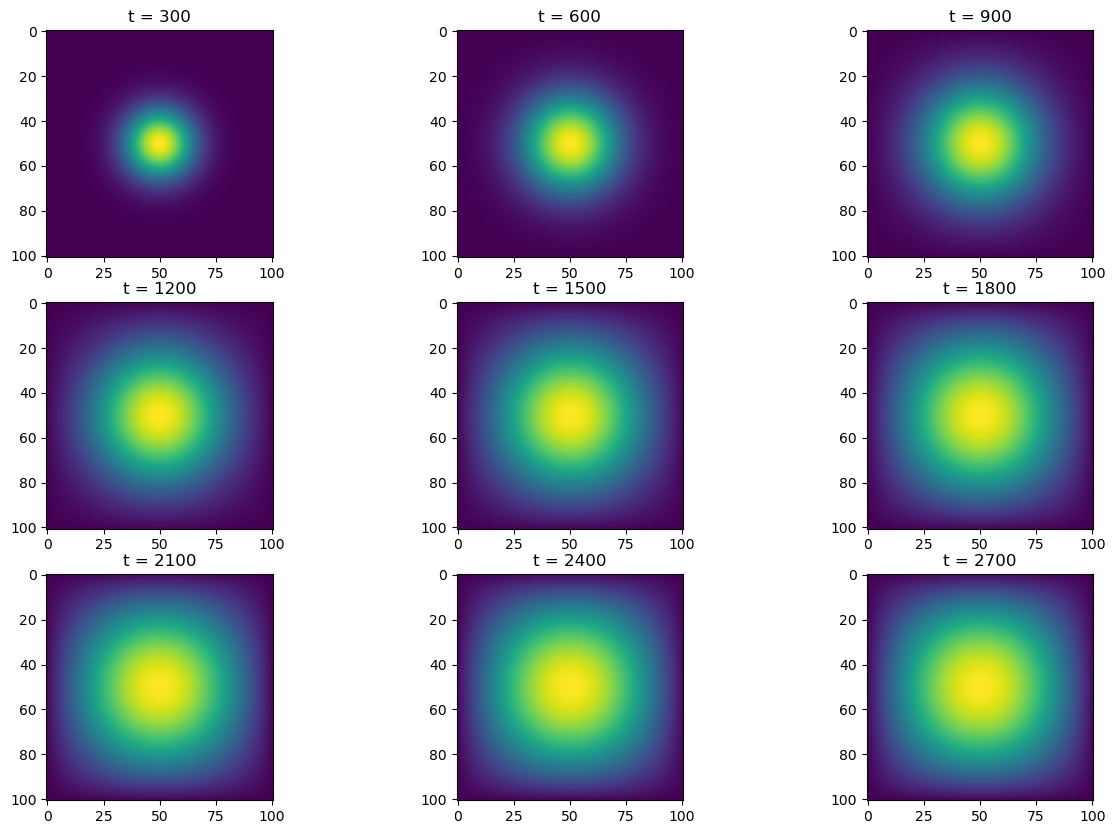

In [10]:
jitted_advance_time_matvecmul = jax.jit(advance_time_matvecmul)
A = get_sparse_A(N)
simulate(jitted_advance_time_matvecmul, A, u0, epsilon)

In [11]:
%%timeit
u = jitted_advance_time_matvecmul(A, u0, epsilon)
for t in range(2, 2701):
    u = jitted_advance_time_matvecmul(A, u, epsilon)

13.7 s ± 721 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


With an average runtime of `13.7s`, using the sparse matrix and jitted function improved our speed by about $10$x that using normal Python matrix multiplication.  

### Direct Numpy

What if we cut out the matrix multiplication and simply use numpy vectorized operations? We can use the `np.roll` method to "shift" our `u` vector around, and by adding and scaling these numpy arrays, we can essentially perform the matrix multiplication itself. 

To calculate the $t+1$ value for each entry, it requires the values to the immediate left, right, top, and bottom. For completeness, we'll handle the border entries by padding our solution array with `0`s on the sides. We'll "roll" the padded `u` to the left by $1$, right by $1$, left by $N+2$ (this gets the bottom entry), and right by $N+2$ (this gets the top entry). Then we fill in the appropriate scalars, sum it up, multiply by $\epsilon$, and add it to the initial heat value. This is all done with `advance_time_numpy'.

In [20]:
def advance_time_numpy(u, epsilon):
    # padding, flattening
    N = u.shape[0]
    u_padded = np.append(u, np.zeros((1, N)), axis=0)
    u_padded = np.append(np.zeros((1, N)), u_padded, axis=0)
    u_padded = np.append(u_padded, np.zeros((N+2, 1)), axis=1)
    u_padded = np.append(np.zeros((N+2, 1)), u_padded, axis=1)
    u_padded = u_padded.flatten()
    
    # Calculating approximate temperature changes for all points, reshaping to original size
    deltas = epsilon*(-4*u_padded + np.roll(u_padded, 1) + np.roll(u_padded, -1) + np.roll(u_padded, N+2) + np.roll(u_padded, -N-2))
    deltas = deltas.reshape((N+2, N+2))
    deltas = deltas[1:-1,1:-1]
    return u + deltas

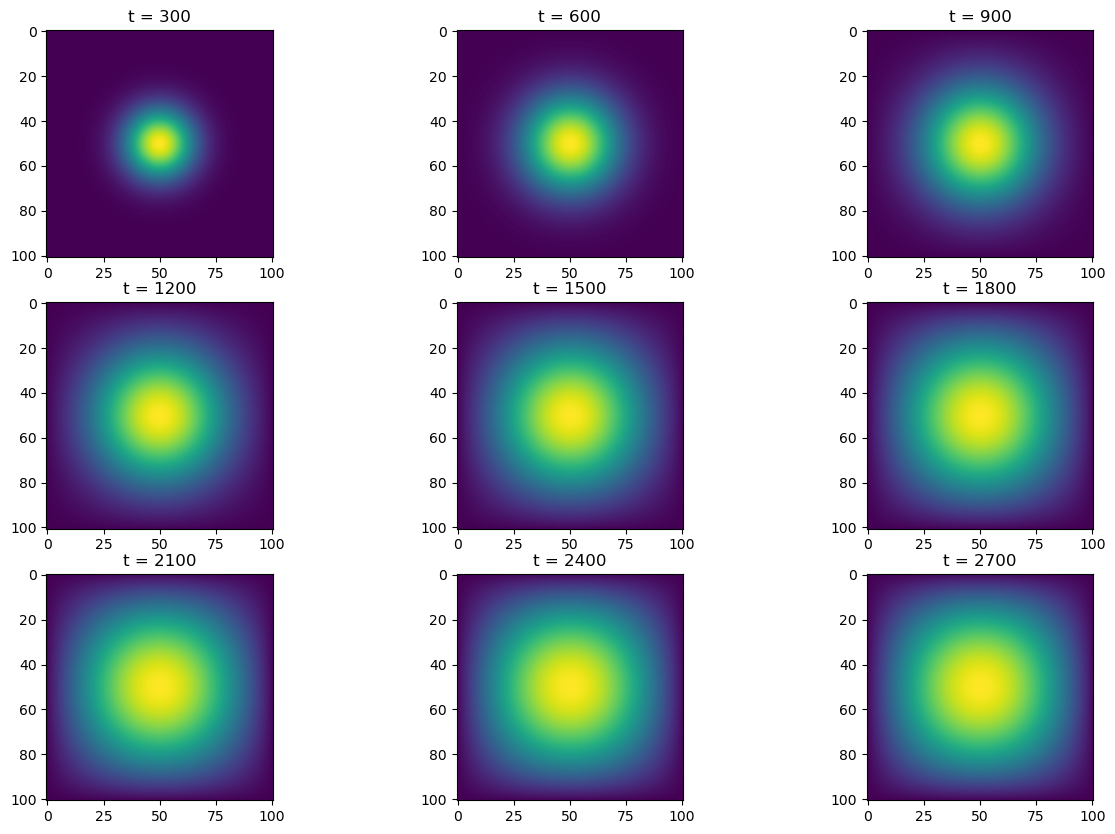

In [21]:
simulate2(advance_time_numpy, u0, epsilon)

In [22]:
%%timeit
u = advance_time_numpy(u0, epsilon)
for t in range(2, 2701): 
    u = advance_time_numpy(u, epsilon)

452 ms ± 41.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


With an average runtime of `0.452s`, using normal numpy vectorized operations outperformed matrix multiplication (part 1) by about $300$x. 

### Numpy (feat. Jax)

Finally, let's see how much faster we can get with just-in-time compilation by making a new function (similar to `advance_time_numpy`) called `advance_time_jax` and jitting it. 

In [27]:
def advance_time_jax(u, epsilon):
    # padding, flattening
    N = u.shape[0]
    u_padded = jnp.append(u, jnp.zeros((1, N)), axis=0)
    u_padded = jnp.append(jnp.zeros((1, N)), u_padded, axis=0)
    u_padded = jnp.append(u_padded, jnp.zeros((N+2, 1)), axis=1)
    u_padded = jnp.append(jnp.zeros((N+2, 1)), u_padded, axis=1)
    u_padded = u_padded.flatten()
    
    # Calculating approximate temperature changes for all points, reshaping to original size
    deltas = epsilon*(-4*u_padded + jnp.roll(u_padded, 1) + jnp.roll(u_padded, -1) + jnp.roll(u_padded, N+2) + jnp.roll(u_padded, -N-2))
    deltas = deltas.reshape((N+2, N+2))
    deltas = deltas[1:-1,1:-1]
    return u + deltas

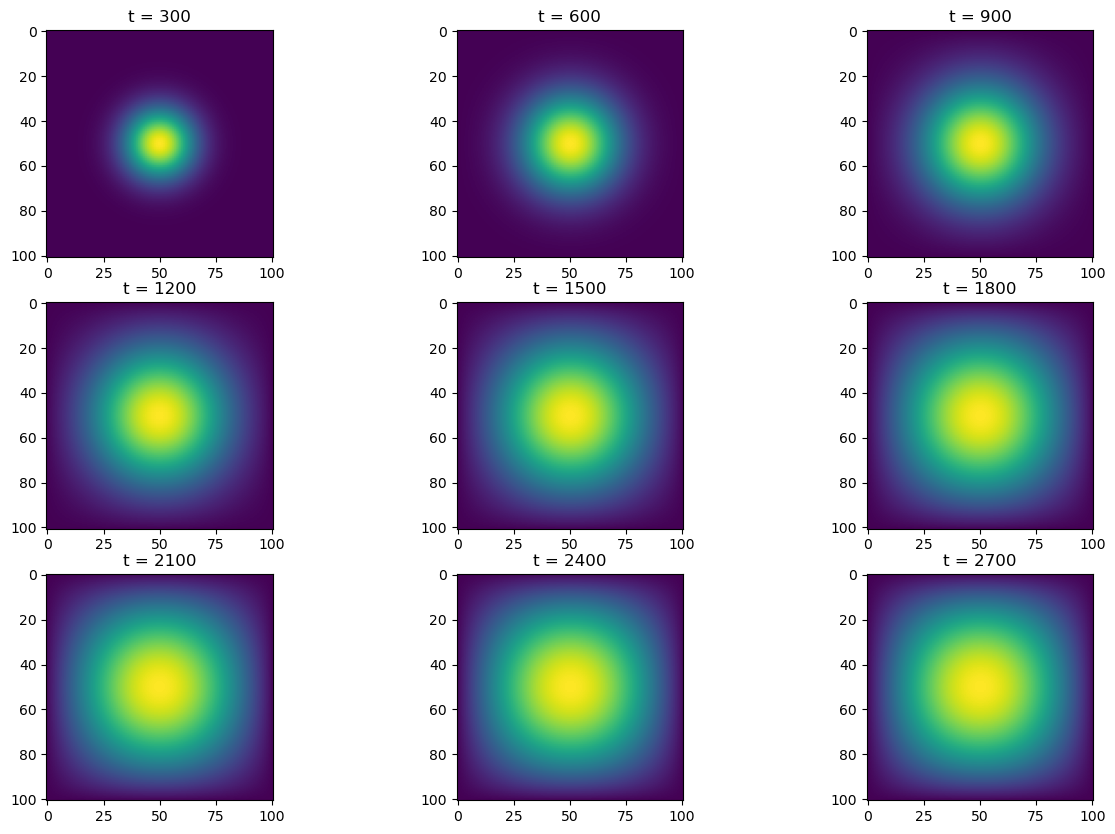

In [28]:
jitted_advance_time_jax = jax.jit(advance_time_jax)
simulate2(jitted_advance_time_jax, u0, epsilon)

In [29]:
%%timeit
u = jitted_advance_time_jax(u0, epsilon)
for t in range(2, 2701): 
    u = jitted_advance_time_jax(u, epsilon)

67.8 ms ± 10.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


With jax's jit, we got a runtime of `0.0678s` and improved from using normal numpy by around $6$x. 

### Comparisons and Personal Remarks

As far as performance, the jitted numpy method far outperformed all the other methods, because 1) matrix multiplication in methods 1 and 2 is very slow compared to vectorized numpy operations (inner products on inner products...) and 2) JAX allows us to give us some Python flexibility for increased performance. In terms of implementation and writing, using linear algebra and matrices was the "cleanest", in that to move forward one time-step, one simply had to do one matrix-vector multiplication. However, "brute-forcing" with numpy arrays was easier to conceptually build up and ultimately performed faster as well. For a final remark, I would definitely settle for jax numpy implementation.